# 미션 6 X-Ray 사진으로 폐렴 여부를 구분하는 분류(Classification) 모델을 만들기

## 데이터 소개 — Chest X-Ray Images (Pneumonia)

> **분석 목적:** 흉부 X-Ray 이미지를 입력받아 정상(`NORMAL`)과 폐렴(`PNEUMONIA`)을 구분한다.
>
> **출처:** [Kaggle 데이터셋 소개](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data) · [관련 논문 및 Figure S6](https://www.cell.com/cell/fulltext/S0092-8674(18)30154-5)

### 데이터 출처와 구성 - 요약한 것

| 항목 | 내용 |
|---|---|
| 대상 | 중국 광저우 여성·어린이 의료센터의 **1~5세 소아 환자** |
| 수집 배경 | 과거 진료 과정에서 촬영한 흉부 X-Ray 영상을 모은 데이터 |
| 촬영 방향 | 전후방향(AP) |
| 파일 형식 | JPEG 이미지 |
| 폴더 구성 | `train`, `val`, `test` 아래에 `NORMAL`, `PNEUMONIA` 폴더가 있음 |
| 분류 대상 | 정상과 폐렴의 **이진 분류**. 세균성·바이러스성 폐렴은 모두 `PNEUMONIA`로 묶음 |
| 사전 품질 관리 | 품질이 낮거나 판독하기 어려운 영상을 제외했다고 설명 |
| 정답 검토 | 의사 2명이 진단을 검토했으며, 평가 데이터는 제3의 전문가도 확인했다고 설명 |

### 폐렴 예시 이미지에 대한 설명 - AI 사용해서 논문 확인

관련 논문의 **Figure S6 설명**을 요약했다. 이 표는 대표적인 예시를 이해하기 위한 것이며, 밝기나 특정 모양만으로 폐렴을 판단하는 규칙은 아니다.

| 예시 | 본문에서 설명하는 특징 |
|---|---|
| 정상 | 폐가 비교적 맑게 보이고 비정상적으로 하얗게 보이는 영역이 없음 |
| 세균성 폐렴 | 특정 폐엽에 국소적으로 하얗게 뭉쳐 보이는 양상. 해당 예시는 오른쪽 위 폐엽을 가리킴 |
| 바이러스성 폐렴 | 양쪽 폐에 더 넓게 퍼진 간질성 양상을 예시로 제시 |

### 실제 파일 수 확인

| 구분 | NORMAL | PNEUMONIA | 합계 |
|---|---:|---:|---:|
| 원본 train | 1,341 | 3,875 | 5,216 |
| 원본 val | 8 | 8 | 16 |
| 원본 test | 234 | 390 | 624 |
| **합계** | **1,583** | **4,273** | **5,856** |

데이터셋 소개에는 **5,863장**이라고 기재되어 있으나, 이번 작업에서 실제 이미지 파일을 세어 확인한 수는 **5,856장**이다. 분석에는 실제 확인한 장수를 사용하며, 소개와 차이가 나는 이유는 아직 확인하지 않았다. 


In [2]:
import torch

print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

GPU 사용 가능: True
GPU 이름: Tesla T4


## 데이터 로드
> **목적:** 데이터를 불러오고 구성을 확인한다.
>
> **참고:** kaggle 제공 자료 - https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- device 설정
- 학습 위치 확인 (GPU 무조껀 필요 - colap연결)
- train: 훈련 데이터, test: 테스트 데이터, val: 검증 데이터 다운로드 받기
- 데이터셋 로드 생성
- 데이터 확인 - 각각 몇장인지, 어떤 싸이즈인지
- print 해서 각각 이미지 확인
## EDA
> **목적** 데이터 특성과 문제점을 파악하고 전처리, 평가 방법의 근거를 생각한다.
>
> **참고** 강사님자료 PRACTICE-1, HTML
- 전부 가장 많은 클래서로 예측했을 떄의 정확도 확인
- 실제 배열 읽기 size, channel, dtupe, range
- 학습 데이터에서 정상·폐렴 이미지를 각각 15장씩 랜덤으로 보기
- 클래스별로 5장씩 3회 시각화하여 밝기, 구도, 잘림 등 보기
- 검증 데이터는 16장 전체를 확인
- 관찰한 특징과 추가 확인이 필요한 사항을 기록
- size -> 어떤 싸이즈로 맞추면 좋을지 사전에 생각하기
- train, val, test에 중복 확인(데이터 누수 방지)
- 검증 데이터가 16장으로 적다는 점을 확인
- 검증 점수의 변동 가능성을 고려하여 데이터 분할 방식을 설정
- 테스트 데이터는 최종 평가용으로 유지
## 전처리
> **목적** 학습하기 좋은 상태를 만든다.
>
> **참고** 강의자료 PRACTICE-1, CodeIt baseline 사용
- 데이터 전처리 정의(마크다운 만들기)
- 이미 분리된 학습·검증·테스트 데이터의 전처리 방법을 정의한다.
- 학습 데이터에만 랜덤 크롭과 회전으로 데이터 증강을 적용한다.
- 모든 데이터에 텐서 변환과 정규화를 적용한다.
- 랜덤 크롭과 회전을 증강 후보로 검토한다. -> print 5장 찍어서 확인하기
- 변환된 이미지를 확인한 후 적용 여부와 강도를 결정한다.
- train-val은 train에서 추가로 20%를 가져와 val로 만들고 중복데이터가 없는지 다시 확인한다.
## 모델 학습
> **목적** 4가지 모델 중 가장 정확도가 높은 모델을 찾기
>
> **참고** CodeIt baseline 사용
- Transfer Learning - 코드잇 제공자료 활용
- Fine-Tuning 적용하기
- Custom CNN, ResNet18 Frozen, Partial Fine-Tuning, Full Fine-Tuning 도 함께 적용하여 비교하기
- 각 실험에서 검증 성능이 가장 좋은 모델을 별도 파일로 저장
- 실험 설정과 학습·검증 지표를 기록하여 비교
- bar-plot으로 최종 성능비교
- 모델별 학습 곡선을 2×2 배치로 그린다.
- 각 그래프의 가로축은 epoch, 세로축은 loss로 설정
- 각 그래프에 train loss와 val loss 두 선을 표시
- 최종 평가 지표는 막대그래프로 비교
## 예측 - 검증 데이터 사용
## 검증 성능 평가 및 모델 선택
> **목적:** 네 가지 실험의 분류 성능을 비교한다.

- 검증 Accuracy가 가장 높은 시점의 모델을 저장한다.
- Precision, Recall, F1-score도 함께 확인하여 성능을 해석한다.
## 테스트 데이터 최종평가

## 데이터 로드

In [6]:
# 캐글 데이터 불러오기

import kagglehub 

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [8]:
# 어디서 학습할것인가? 학습에 사용할 장치 설정

import torch
import os

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu"
"")
print(device)

cuda


In [9]:
# 데이터 로드 준비중 -> 파일경로 확인하는 셸

train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

In [10]:
# 데이터 불러오기

from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)
print(type(class_names)) # 무엇인가?
print(len(class_names)) # 몇개인가?


Class names: ['NORMAL', 'PNEUMONIA']
<class 'list'>
2


In [11]:
# 안에 들어있는 클래스 수가 2개인걸로 보여서 데이터셋 열어보기

print("데이터 갯수", len(train_dataset))

데이터 갯수 5216


In [8]:
# 데이터 확인 - 각각 몇장인지, 어떤 싸이즈인지

from PIL import Image
import numpy as np

# 학습 데이터셋의 첫 번째 이미지 파일 경로와 정답 번호
image_path, label = train_dataset.samples[0]

# 전처리를 거치지 않은 원본 파일 열기
with Image.open(image_path) as img:
    print("원본 크기(너비, 높이):", img.size)
    print("이미지 모드:", img.mode)  # L: 흑백, RGB: 컬러

    # 이미지를 숫자 배열로 바꾸기
    arr = np.array(img)

print("배열 모양:", arr.shape)      # 흑백: (높이, 너비), RGB: (높이, 너비, 3)
print("자료형:", arr.dtype)         # 숫자를 저장하는 자료형
print("픽셀 최솟값:", arr.min())
print("픽셀 최댓값:", arr.max())

원본 크기(너비, 높이): (2090, 1858)
이미지 모드: L
배열 모양: (1858, 2090)
자료형: uint8
픽셀 최솟값: 0
픽셀 최댓값: 255


| 출력 | 의미 |
|---|---|
| `img.size: (2090, 1858)` | **너비, 높이** 순서 |
| `모드: L` | 밝기만 표현하는 **흑백 1채널** |
| `arr.shape: (1858, 2090)` | 배열에서는 **높이, 너비** 순서 |
| `uint8` | 0~255의 정수를 저장하는 자료형 |
| 최솟값 0, 최댓값 255 | 이 사진에 검정(0)부터 흰색(255)까지 포함됨 |

# **결론 적기** 감상평 금지
>

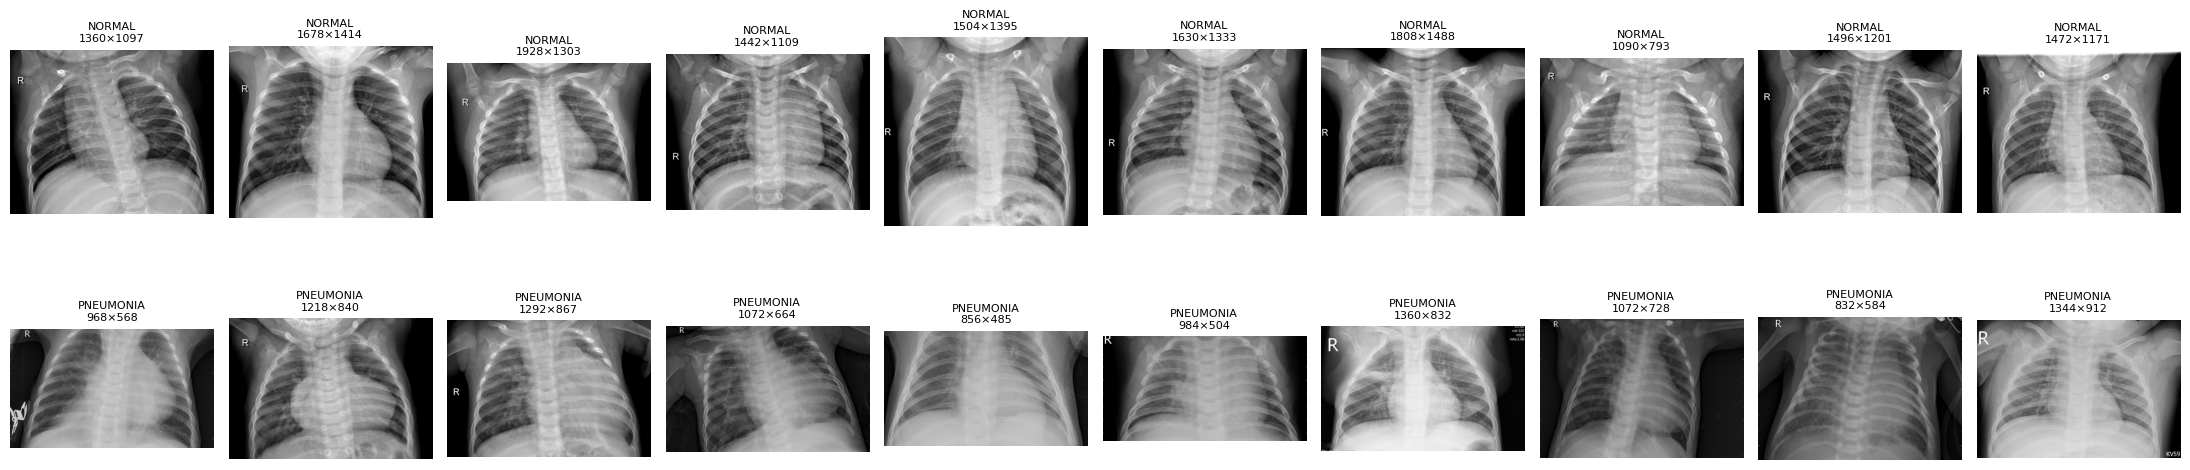

In [9]:
# print 해서 각각 이미지 확인 

import random
import matplotlib.pyplot as plt
from PIL import Image

# 같은 코드를 다시 실행해도 같은 사진을 뽑도록 설정
rng = random.Random(42)

# 2행 × 10열의 그림 칸 만들기
fig, axes = plt.subplots(2, 10, figsize=(22, 6))

for row, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
    class_id = train_dataset.class_to_idx[class_name]

    # 해당 클래스의 이미지 경로만 모으기
    paths = [
        path for path, label in train_dataset.samples
        if label == class_id
    ]

    # 중복 없이 10장 무작위 선택
    selected_paths = rng.sample(paths, 10)

    for col, path in enumerate(selected_paths):
        ax = axes[row, col]  # 사진을 넣을 칸 선택

        # 전처리 전 원본 이미지 열기
        with Image.open(path) as img:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"{class_name}\n{img.width}×{img.height}", fontsize=8)

        ax.axis("off")  # 좌표 눈금 숨기기

plt.tight_layout()
plt.show()

## 그래서 폐렴이라고 어떻게 판단하는가?
> 여기까지 데이터에 대한 정보를 보았는데 그럼 이미지를 보고 우리는 어떻게 판단할 수 있나? 폐렴이라고
>
> README를 보고 이야기 해보자


## EDA

> **목적:** 데이터 특성과 문제점을 파악하고 전처리·평가 방법의 근거를 생각한다.
>
> **참고:** 강사님 자료 PRACTICE-1, 이미지 분류 HTML

### 내가 세운 계획
1. 전부 가장 많은 클래스로 예측했을 때의 정확도 확인
2. 실제 배열을 읽어 size, channel, dtype, range 확인
3. 학습 데이터에서 정상·폐렴 이미지를 각각 15장씩 랜덤으로 보기
4. 클래스별로 5장씩 3회 시각화하여 밝기·구도·잘림 등을 보기
5. 검증 데이터는 16장 전체 확인
6. 관찰한 특징과 추가 확인이 필요한 사항 기록
7. 어떤 크기로 맞추면 좋을지 사전에 생각하기
8. train·val·test 중복 확인 — 데이터 누수 점검
9. 검증 데이터가 16장으로 적다는 점 확인
10. 검증 점수의 변동 가능성을 고려하여 데이터 분할 방식 설정
11. 테스트 데이터는 최종 평가용으로 유지

### 읽는 방법
각 단계는 **내 계획 → 목적 → 의사코드 → 실제 코드와 출력 → 결과 해석** 순서로 읽는다.
3번과 4번은 같은 샘플을 뽑아 세 번에 나누어 보여주므로 한 구간에 묶었다.
맨 먼저 나오는 준비 코드는 이미지의 목록표를 만드는 단계이며, 모델 학습은 하지 않는다.

| 변수 | 의미 |
|---|---|
| `files` | 이미지가 어느 분할·클래스에 속하는지, 파일 경로가 무엇인지 담은 표 |
| `counts` | 분할별 정상·폐렴 이미지 개수와 기준선 표 |
| `arr` | 원본 이미지 한 장의 픽셀을 담은 숫자 배열 |
| `meta` | 이미지 목록에 원본 크기·채널 등의 정보를 붙인 표 |
| `train_meta` | `meta`에서 학습 데이터만 고른 표 |
| `proposal` | 새 학습·검증 분할 후보를 기록한 표. 현재 로더에는 자동 적용되지 않음 |


### EDA 실행 안내

> **내 계획:** 준비: 데이터 위치와 이미지 목록 만들기
>
> **목적:** 파일을 하나씩 검사하기 전에 사용할 이미지 경로를 표로 정리한다.

**실행 상태:** 원본 데이터에서가 아닌 캐글에서 가져와 데이터 EDA실시, GPU가 학습하지 않는다.

In [10]:
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import hashlib
import re
from IPython.display import display

SEED = 42
CLASSES = ["NORMAL", "PNEUMONIA"]
# train/val/test 폴더가 모두 있는 데이터 루트를 찾는다.
candidates = [Path.cwd() / "chest_xray",
              Path("/Users/codeit/CodeIt-ouo/Mission_6/chest_xray")]
if "train_dir" in globals():
    candidates.insert(0, Path(train_dir).parent)
if "path" in globals() and isinstance(path, (str, Path)):
    candidates.extend([Path(path) / "chest_xray", Path(path)])
def is_data_root(folder):
    return all((folder / split / cls).is_dir()
               for split in ["train", "val", "test"] for cls in CLASSES)
DATA_ROOT = next((p for p in candidates if is_data_root(p)), None)
if DATA_ROOT is None:
    import kagglehub
    downloaded = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
    DATA_ROOT = next((p for p in [downloaded, downloaded / "chest_xray",
                                downloaded / "chest_xray/chest_xray"] if is_data_root(p)), None)
if DATA_ROOT is None:
    raise FileNotFoundError("train/val/test가 있는 chest_xray 경로를 확인하세요.")

# 하위의 중복 데이터 폴더를 재귀 탐색하지 않고 각 클래스 폴더만 읽는다.
records = []
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        for file in sorted((DATA_ROOT / split / cls).iterdir()):
            if file.is_file() and file.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                records.append({"split": split, "class": cls, "file": str(file), "name": file.name})
files = pd.DataFrame(records)
print("EDA 데이터 위치:", DATA_ROOT)
print("전체 이미지:", len(files), "장")

EDA 데이터 위치: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
전체 이미지: 5856 장


### 1. 클래스 분포와 다수 클래스 기준선

> **내 계획:** 전부 가장 많은 클래스로 예측했을 때의 정확도 확인
>
> **목적:** 사진을 구별하지 않아도 얻는 정확도를 알아야 학습한 모델의 성능을 해석할 수 있다.

**결론 : 베이스라인으로 준 파일은 기준선이 다 다르다. 따라서 이 기준이 아닌 다시 비율로 나눠 수정한다.**

In [11]:
counts = pd.crosstab(files["split"], files["class"]).reindex(["train", "val", "test"])
counts["TOTAL"] = counts.sum(axis=1)
majority_class = counts.loc["train", CLASSES].idxmax()
counts["majority_baseline_pct"] = counts[majority_class] / counts["TOTAL"] * 100
display(counts.round(2))
print("사진을 보지 않고 항상 답할 클래스:", majority_class)
print("기준선이 높더라도 소수 클래스를 전혀 맞히지 못할 수 있다.")

class,NORMAL,PNEUMONIA,TOTAL,majority_baseline_pct
split,,,,
train,1341,3875,5216,74.29
val,8,8,16,50.00
test,234,390,624,62.50


사진을 보지 않고 항상 답할 클래스: PNEUMONIA
기준선이 높더라도 소수 클래스를 전혀 맞히지 못할 수 있다.


### 2. 실제 배열: 크기·채널·자료형·값 범위

> **내 계획:** 실제 배열 읽기: size, channel, dtype, range
>
> **목적:** 전처리 전 이미지의 크기와 숫자 형태를 확인한다. 한 장만 본 결과를 전체에 적용하지 않도록 전체 형식도 조사한다.

**결론 : 데이터 학습에 방해되는 요소가 없는지 확인, 그리고 채널이 다른건 없는지도 확인**

In [12]:
info = []

# 학습 이미지의 경로를 하나씩 가져오기
for file in files.loc[files["split"] == "train", "file"]:
    with Image.open(file) as img:
        info.append({
            "file": file,
            "너비": img.width,
            "높이": img.height,
            "모드": img.mode,
        })

info = pd.DataFrame(info)

# 가로세로 비율: 값이 클수록 가로로 긴 이미지
info["가로세로비"] = info["너비"] / info["높이"]

# 여기서는 전체 픽셀 수가 적은 이미지를 '작은 이미지'로 보기
info["픽셀수"] = info["너비"] * info["높이"]

In [13]:
print(info["모드"].value_counts())

모드
L      4933
RGB     283
Name: count, dtype: int64


학습 데이터에 1채널 흑백 이미지 4,933장과 3채널 RGB 이미지 283장이 섞여 있다. 모델 입력에 맞춰 채널을 통일할 필요가 있다.

/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 44596 (\N{HANGUL SYLLABLE GIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_104/2453702786.py:18: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

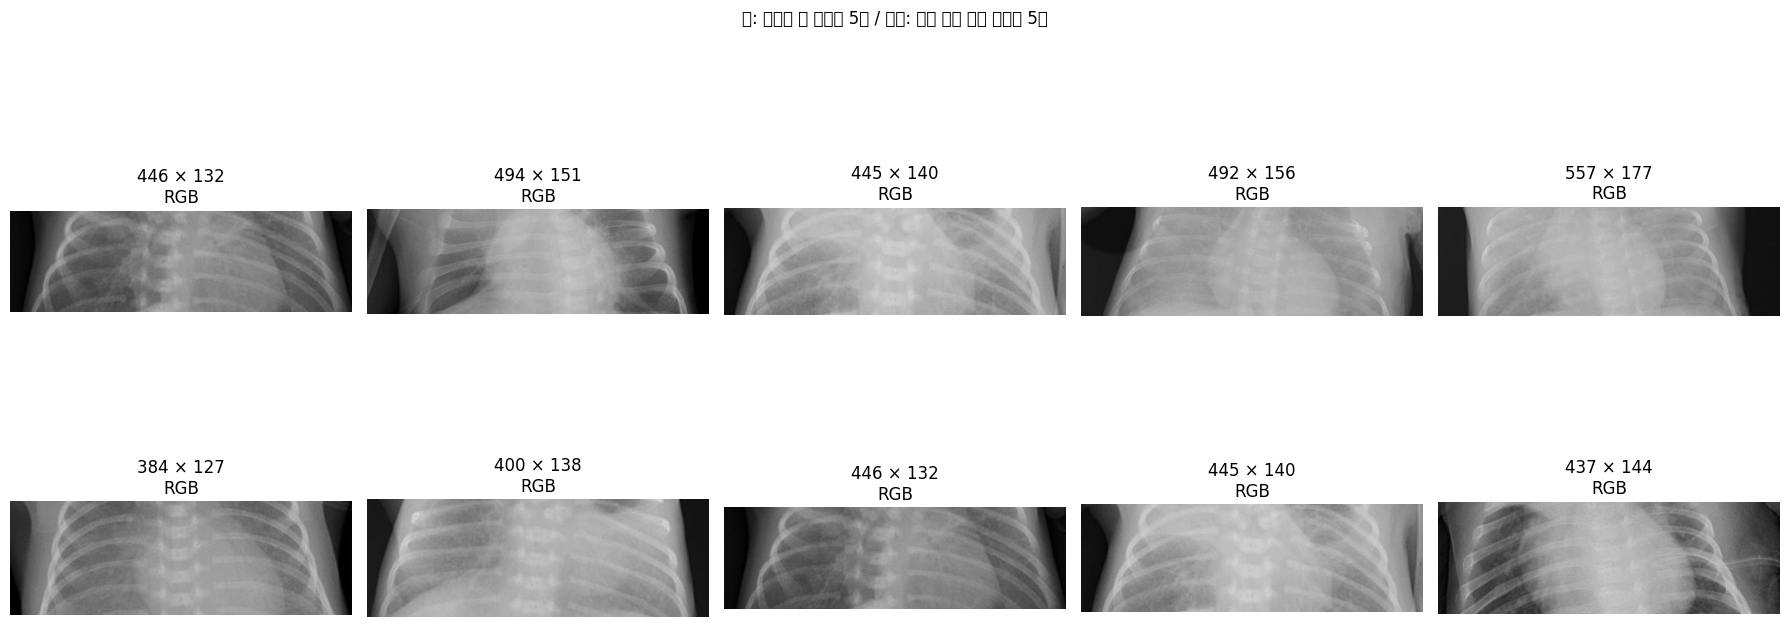

In [14]:
# 확인할 이미지 선택
wide = info.nlargest(5, "가로세로비")
small = info.nsmallest(5, "픽셀수")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, selected in enumerate([wide, small]):
    for col, (_, item) in enumerate(selected.iterrows()):
        with Image.open(item["file"]) as img:
            axes[row, col].imshow(img, cmap="gray")

        axes[row, col].set_title(
            f'{item["너비"]} × {item["높이"]}\n{item["모드"]}'
        )
        axes[row, col].axis("off")

plt.suptitle("위: 가로로 긴 이미지 5장 / 아래: 픽셀 수가 적은 이미지 5장")
plt.tight_layout()
plt.show()

가로로 긴 학습 이미지가 관찰되었다. 정사각형으로 크기를 변경할 때 형태가 왜곡되거나, 크롭 과정에서 폐 일부가 잘릴 가능성이 있어 전처리 전후 이미지를 비교할 예정이다.

In [15]:
# 내가 생각한 모든걸 손상도로 처리한 유즈 코드
# for cls in CLASSES:
#     file = files.query("split == 'train' and `class` == @cls").iloc[0]["file"]
#     with Image.open(file) as img:
#         arr = np.array(img)
#         print(cls, Path(file).name)
#         print("size:", img.size, "mode:", img.mode, "channels:", len(img.getbands()))
#         print("shape:", arr.shape, "dtype:", arr.dtype, "range:", (arr.min(), arr.max()))
#         print("픽셀 평균:", round(float(arr.mean()), 2), "중앙값:", float(np.median(arr)))
#         print()

# metadata, read_errors = [], []
# # 전체를 실제로 디코딩해서 손상 파일 여부를 확인한다.
# for row in files.to_dict("records"):
#     try:
#         with Image.open(row["file"]) as img:
#             img.load()
#             metadata.append({**row, "width": img.width, "height": img.height,
#                              "mode": img.mode, "channels": len(img.getbands())})
#     except Exception as error:
#         read_errors.append({"file": row["file"], "error": str(error)})
# meta = pd.DataFrame(metadata)
# print("읽기 성공:", len(meta), "장 / 읽기 오류:", len(read_errors), "장")
# if read_errors:
#     display(pd.DataFrame(read_errors))
# display(meta.groupby(["split", "mode", "channels"]).size().rename("count").to_frame())

### 3~4. 학습 이미지: 클래스별 15장, 5장씩 3회

> **내 계획:** 정상·폐렴 각각 15장 랜덤 선택 → 5장씩 3회 시각화
>
> **목적:** 두 클래스에서 동일한 수의 사진을 골라 밝기·구도·여백을 살펴본다.

#### 해석과 주의점

시드를 고정하고 각 클래스에서 중복 없이 15장을 고른다. 각 그림의 윗줄은 정상 5장, 아랫줄은 폐렴 5장이다.
총 3개 그림으로 30장을 확인한다. 확대·잘림 없이 원본을 표시하고 8비트 밝기 기준을 통일한다.

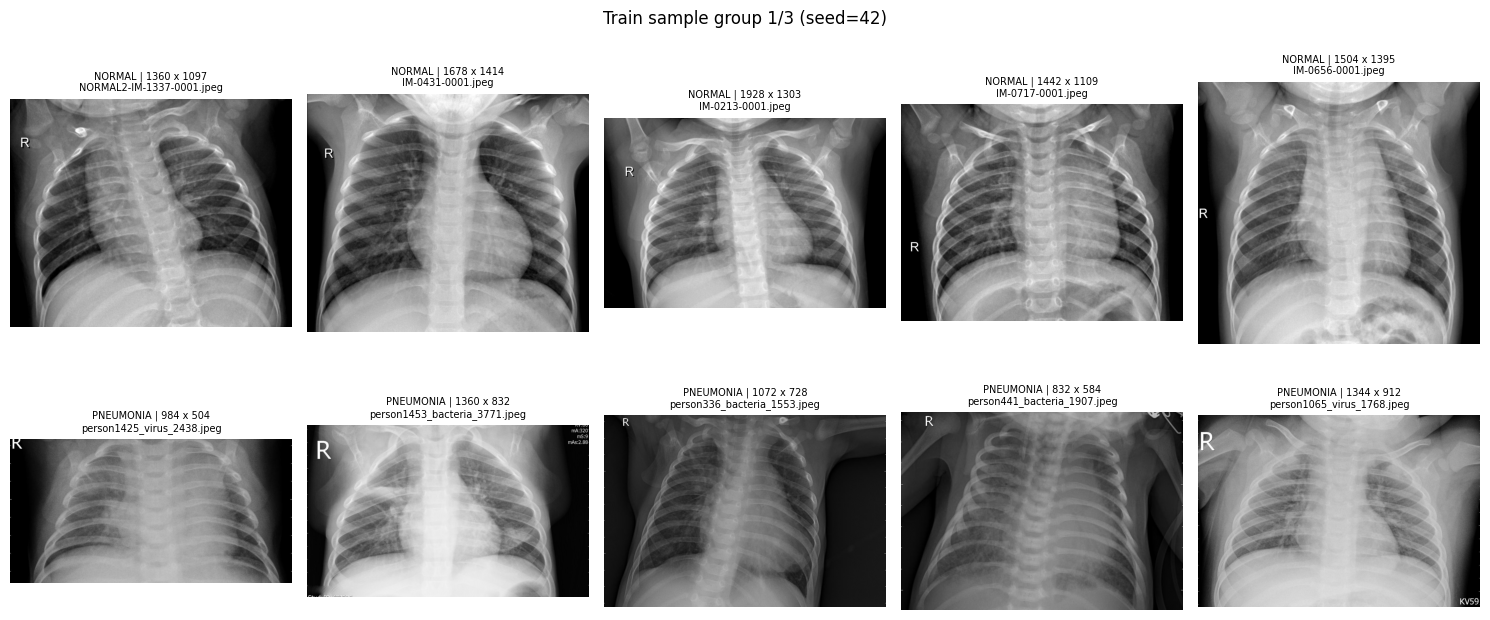

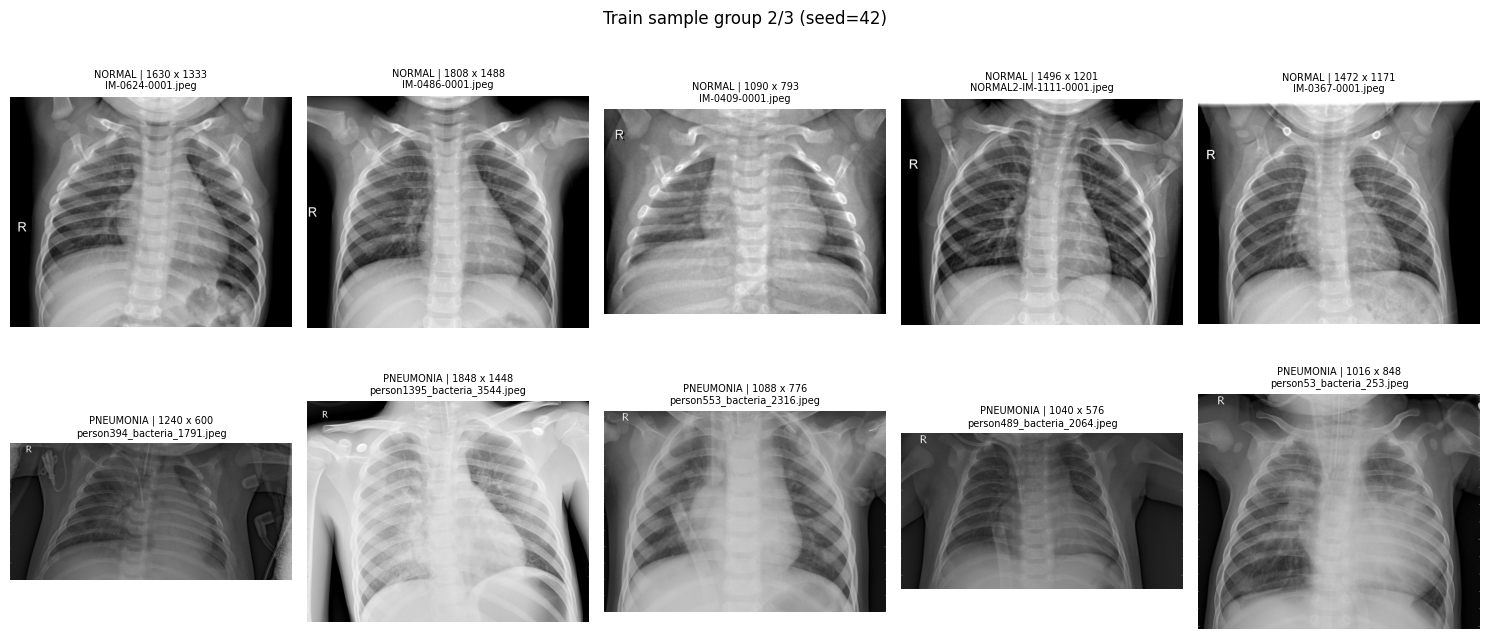

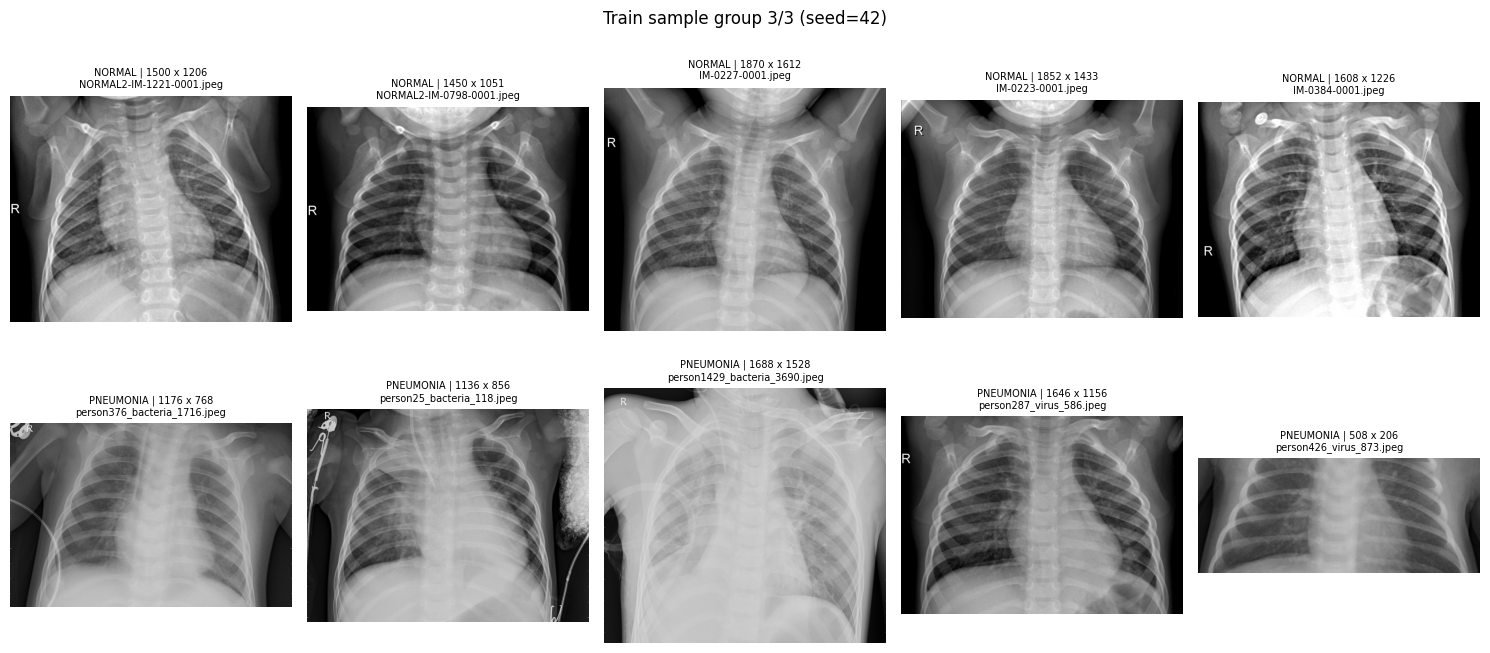

In [16]:
rng = random.Random(SEED)
selected = {}
for cls in CLASSES:
    paths = files.query("split == 'train' and `class` == @cls")["file"].tolist()
    selected[cls] = rng.sample(paths, 15)

for batch in range(3):
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    for row, cls in enumerate(CLASSES):
        for col, file in enumerate(selected[cls][batch * 5:(batch + 1) * 5]):
            with Image.open(file) as img:
                axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=255)
                axes[row, col].set_title(f"{cls} | {img.width} x {img.height}\n{Path(file).name}", fontsize=7)
            axes[row, col].axis("off")
    fig.suptitle(f"Train sample group {batch + 1}/3 (seed={SEED})")
    plt.tight_layout()
    plt.show()

### 5. 제공된 검증 이미지 전체 확인

> **내 계획:** 검증 데이터 16장 전체 확인
>
> **목적:** 학습 중 모델 선택에 사용할 검증 이미지가 어떤 구성인지 살펴본다.

#### 해석과 주의점

현재 val의 정상·폐렴 이미지를 모두 표시한다. 폴더 개수가 바뀌어도 누락되지 않도록 클래스별로 그린다.

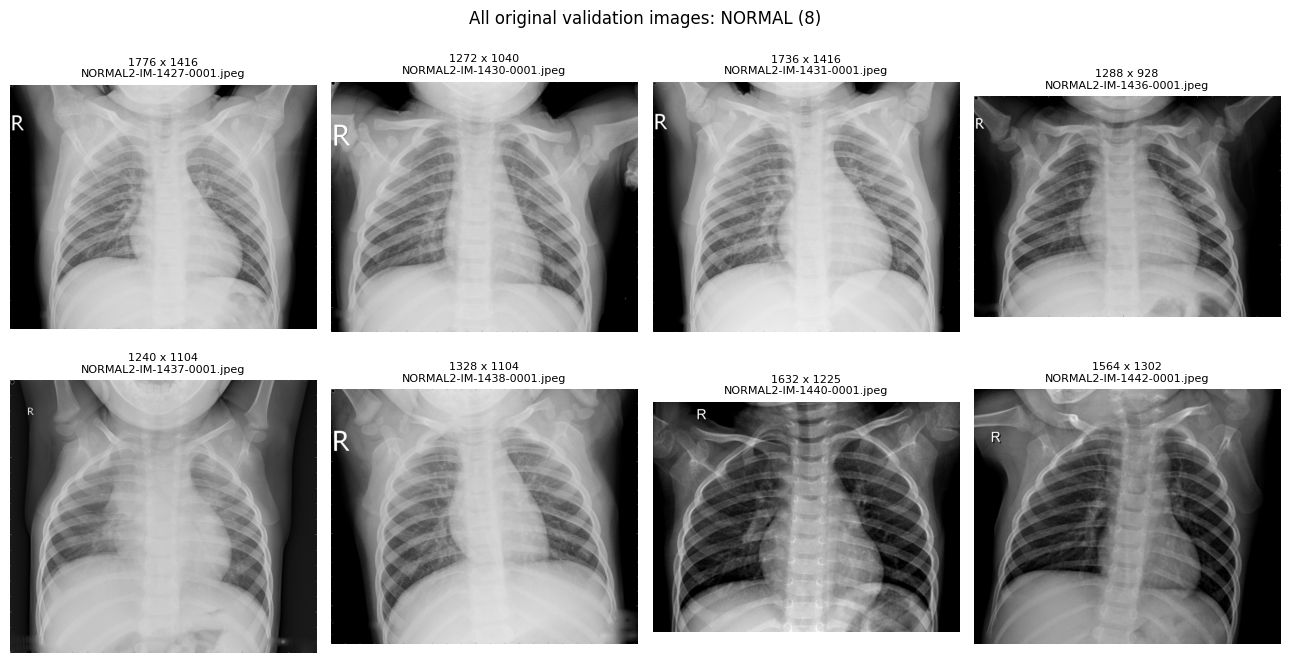

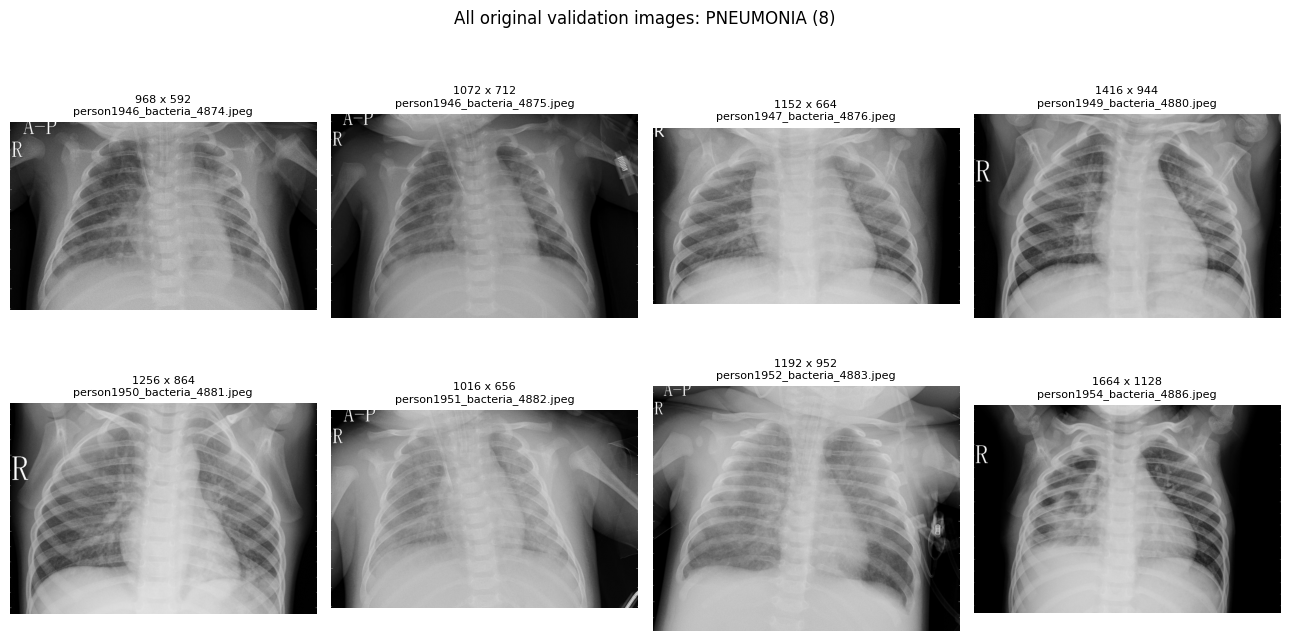

In [17]:
for cls in CLASSES:
    paths = files.query("split == 'val' and `class` == @cls")["file"].tolist()
    fig, axes = plt.subplots((len(paths) + 3) // 4, 4, figsize=(13, 3.5 * ((len(paths) + 3) // 4)), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, file in zip(axes.flat, paths):
        with Image.open(file) as img:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"{img.width} x {img.height}\n{Path(file).name}", fontsize=8)
    fig.suptitle(f"All original validation images: {cls} ({len(paths)})")
    plt.tight_layout()
    plt.show()

### 6. 관찰 기록

> **내 계획:** 관찰한 특징과 추가 확인이 필요한 사항 기록
>
> **목적:** 측정한 사실·샘플에서 본 특징·추가로 확인할 질문을 구분해 정리한다.

#### 아래 코드와 결과를 읽는 방법

학습 원본은 L 4,933장과 RGB 283장이고, 크기 조합은 4,366개다. 아래 관찰 문장은 실제 그림을 다시 보면서 내 말로 수정해도 된다.

#### 해석과 주의점

아래 자동 요약은 파일의 측정 결과이다. 이미지 밝기·여백·구도에 관한 관찰은 위 그림을 근거로 별도 기록한다.
사진만으로 정상·폐렴을 직접 판독하지 않고 제공된 라벨을 사용한다. 샘플에서 본 특징을 전체 데이터로 일반화하지 않는다.

**선택된 샘플에서 관찰한 내용**
- 사진마다 밝기·대비·가로세로 비율·흉부 주변 여백이 다르다. 일부에는 R, AP 같은 촬영 표식이 있다.
- `person426_virus_873.jpeg`는 508×206의 가로로 긴 영상이고, 다른 샘플보다 보이는 범위가 좁다. 원본을 더 잘라내는 증강은 신중히 검토한다.
- 검증의 `person1946_bacteria_4874.jpeg`, `person1946_bacteria_4875.jpeg`는 같은 환자 추정 접두어를 공유한다. 16장을 16명의 독립 환자로 간주하지 않는다.
- 위 관찰은 선택된 샘플에 한정된다. 밝기나 촬영 표식을 폐렴의 판독 기준으로 삼지 않는다.


In [18]:
# 전체 이미지 목록에 크기·모드 정보를 추가한다.
metadata = []

for row in files.to_dict("records"):
    with Image.open(row["file"]) as img:
        metadata.append({
            **row,                       # 기존 경로·클래스 정보 유지
            "width": img.width,           # 너비
            "height": img.height,         # 높이
            "mode": img.mode,             # L 또는 RGB
            "channels": len(img.getbands())  # 채널 수
        })

# 뒤쪽 EDA 셀에서 사용할 표
meta = pd.DataFrame(metadata)

print("이미지 정보 정리 완료:", len(meta), "장")

KeyboardInterrupt: 

In [ ]:
train_meta = meta.query("split == 'train'").copy()
print("학습 데이터 클래스별 개수:", counts.loc["train", CLASSES].to_dict())
print("학습 원본 모드 분포:", train_meta["mode"].value_counts().to_dict())
print("학습 원본에서 서로 다른 크기 조합:", train_meta[["width", "height"]].drop_duplicates().shape[0])
print("원본 크기가 다양하므로 배치 구성을 위한 입력 크기 통일이 필요하다.")
print("원본 모드와 ImageFolder가 RGB로 변환한 뒤의 채널 수는 다를 수 있다.")

학습 데이터 클래스별 개수: {'NORMAL': 1341.0, 'PNEUMONIA': 3875.0}
학습 원본 모드 분포: {'L': 4933, 'RGB': 283}
학습 원본에서 서로 다른 크기 조합: 4366
원본 크기가 다양하므로 배치 구성을 위한 입력 크기 통일이 필요하다.
원본 모드와 ImageFolder가 RGB로 변환한 뒤의 채널 수는 다를 수 있다.


### 7. 입력 크기 검토: 평균·중앙값·분포

> **내 계획:** size → 어떤 크기로 맞출지 사전에 생각하기
>
> **목적:** 대표적인 원본 크기와 분포를 보고 입력 크기·비율 처리 방법의 근거를 마련한다.

#### 의사코드

```text
학습 이미지마다 너비 ÷ 높이로 비율을 구한다
클래스별 최소·중앙값·평균·최대를 구한다
너비·높이·비율의 분포를 그린다
```

#### 아래 코드와 결과를 읽는 방법

`width`는 너비, `height`는 높이, `aspect_ratio`는 가로세로 비율이다. 그래프의 세로축은 장수라서 클래스 개수가 많은 폐렴 막대가 더 높을 수 있다. 중앙값 크기로 반드시 변환해야 하는 것은 아니다.

#### 해석과 주의점

학습 원본의 크기만으로 입력 크기를 검토한다. 중앙값은 대표 크기이지 반드시 따라야 하는 모델 입력 크기는 아니다.
224×224를 첫 실험 후보로 두되, 비율 유지 리사이즈·패딩과 직접 리사이즈의 차이를 검증 데이터로 비교할 수 있다.
폐 영역이 잘리는 과한 랜덤 크롭은 피하고, 증강 후 이미지를 다시 확인한다.

width                        height                         \
            min  median     mean   max    min  median     mean   max   
class                                                                  
NORMAL      912  1640.0  1667.73  2916    672  1328.0  1381.43  2663   
PNEUMONIA   384  1168.0  1200.48  2772    127   776.0   825.03  2304   

          aspect_ratio                     
                   min median  mean   max  
class                                      
NORMAL            0.88   1.22  1.23  1.81  
PNEUMONIA         0.84   1.49  1.51  3.38

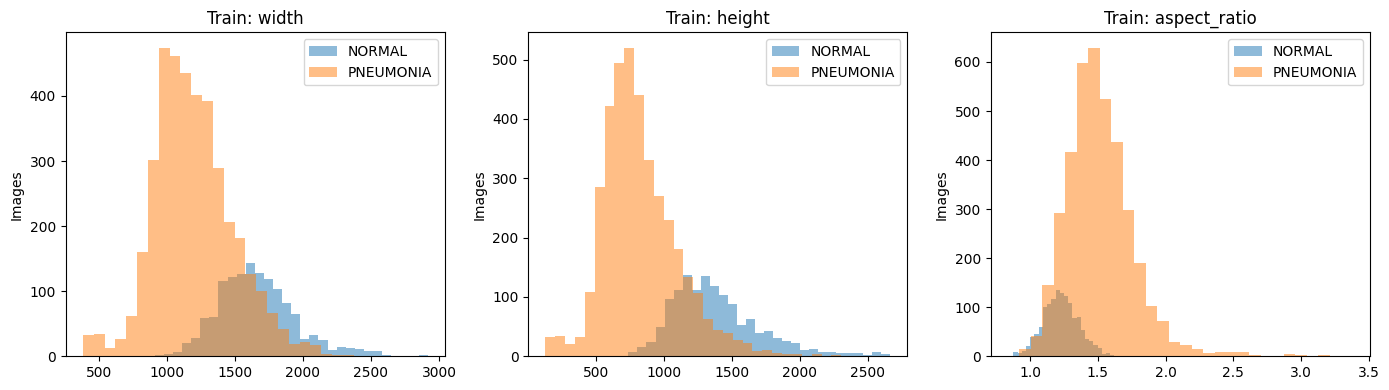

In [ ]:
train_meta["aspect_ratio"] = train_meta["width"] / train_meta["height"]
display(train_meta.groupby("class")[["width", "height", "aspect_ratio"]]
        .agg(["min", "median", "mean", "max"]).round(2))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ["width", "height", "aspect_ratio"]):
    for cls in CLASSES:
        values = train_meta.loc[train_meta["class"] == cls, feature]
        ax.hist(values, bins=30, alpha=0.5, label=cls)
    ax.set_title(f"Train: {feature}")
    ax.set_ylabel("Images")
    ax.legend()
plt.tight_layout()
plt.show()

### 8. 분할 내부·분할 간 중복 검사

> **내 계획:** train·val·test 중복 확인 — 데이터 누수 방지
>
> **목적:** 같은 사진이 학습과 평가 양쪽에 포함되는지 확인한다.

**결론 : 데이터 누수가 없는지 확인한다.**

In [ ]:
file_hashes, pixel_hashes = [], []
for row in meta.to_dict("records"):
    file = Path(row["file"])
    file_hashes.append(hashlib.sha256(file.read_bytes()).hexdigest())
    with Image.open(file) as img:
        rgb = img.convert("RGB")
        digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
        pixel_hashes.append(digest)
meta["file_hash"] = file_hashes
meta["pixel_hash"] = pixel_hashes

for key in ["file_hash", "pixel_hash"]:
    groups = meta.groupby(key)
    duplicated = groups.size()
    repeated = duplicated[duplicated > 1]
    cross = groups["split"].nunique()
    cross_ids = cross[cross > 1].index
    print(f"{key}: 중복 그룹 {len(repeated)}개, 해당 파일 {int(repeated.sum())}장, 분할 간 중복 그룹 {len(cross_ids)}개")
    for split in ["train", "val", "test"]:
        sizes = meta.loc[meta["split"] == split].groupby(key).size()
        print(f"  {split} 내부: 중복 그룹 {(sizes > 1).sum()}개, 추가 사본 {int((sizes - 1).clip(lower=0).sum())}장")
    if len(cross_ids):
        display(meta.loc[meta[key].isin(cross_ids), ["split", "class", "name", key]].sort_values(key).head(30))
print("서로 다른 라벨을 가진 동일 픽셀 그룹:", int((meta.groupby("pixel_hash")["class"].nunique() > 1).sum()))

file_hash: 중복 그룹 30개, 해당 파일 62장, 분할 간 중복 그룹 0개
  train 내부: 중복 그룹 24개, 추가 사본 26장
  val 내부: 중복 그룹 0개, 추가 사본 0장
  test 내부: 중복 그룹 6개, 추가 사본 6장
pixel_hash: 중복 그룹 30개, 해당 파일 62장, 분할 간 중복 그룹 0개
  train 내부: 중복 그룹 24개, 추가 사본 26장
  val 내부: 중복 그룹 0개, 추가 사본 0장
  test 내부: 중복 그룹 6개, 추가 사본 6장
서로 다른 라벨을 가진 동일 픽셀 그룹: 0


테스트 데이터에서는 중복이 보이지만 누수로 판단될 이미지는 없다.

### 9. 검증 16장의 한계

> **내 계획:** 검증 데이터가 16장으로 적다는 점 확인
>
> **목적:** 검증 점수가 한두 장의 정오에 얼마나 민감한지 수치로 확인한다.

#### 의사코드

```text
검증 이미지 수를 확인한다
100 ÷ 검증 이미지 수로 한 장당 정확도 변화량을 계산한다
```

#### 아래 코드와 결과를 읽는 방법

16장이므로 한 장의 정오가 바뀌면 정확도가 6.25%p 변한다. 작은 점수 차이만으로 우열을 단정하기 어렵다.

#### 해석과 주의점

이미지 한 장의 정오가 정확도를 얼마나 바꾸는지 확인한다. 같은 환자 이미지가 포함되면 독립 표본 수도 이미지 수보다 적을 수 있다.

In [ ]:
n_val = int(counts.loc["val", "TOTAL"])
print(f"원래 검증 데이터: {n_val}장")
print(f"한 장의 정오가 바뀌면 정확도는 {100 / n_val:.2f}%p 변화")
print("이 검증 정확도만으로 작은 성능 차이나 일반화 성능을 단정하지 않는다.")

원래 검증 데이터: 16장
한 장의 정오가 바뀌면 정확도는 6.25%p 변화
이 검증 정확도만으로 작은 성능 차이나 일반화 성능을 단정하지 않는다.


### 10. 재분할 후보 설정 (원본 유지)

> **내 계획:** 검증 점수 변동을 고려해 데이터 분할 방식 설정
>
> **목적:** 기존 train에서 더 큰 검증 집합을 만드는 후보를 검토한다. 아직 확정·적용 단계는 아니다.

#### 아래 코드와 결과를 읽는 방법

80:20은 이미지 수가 아니라 그룹 기준이라 장수 비율이 정확히 80:20이 아닐 수 있다. 파일명 그룹은 공식 환자 ID가 아니므로 확인이 필요하다. 이 단계는 심화 부분으로, 우선 후보의 목적과 결과표를 이해하면 된다.

#### 해석과 주의점

첫 후보는 **기존 train을 약 80:20으로 나누는 그룹 기반 분할**이다. 기존 val은 보조 점검용으로 남긴다.
파일명에서 추출한 환자 추정 ID와 같은 픽셀 해시를 묶어 새 train/val 양쪽에 나뉘지 않도록 한다.
`person숫자`, `IM-숫자`, `NORMAL2-IM-숫자`를 파일명 그룹으로 사용한다. 이는 공식 환자 메타데이터로 검증된 ID가 아니므로 환자 수준 독립성을 보장하지 않는다.
고정 시드로 후보를 한 번 만들고 클래스 분포를 확인한다. 정확한 클래스 비율을 강제하는 층화 분할은 아니다.
현재 train_loader를 덮어쓰지 않으며, 실제 학습에 사용하려면 이 후보 표의 파일 목록으로 별도 Dataset을 구성해야 한다.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# 환자로 추정되는 파일명 접두어를 추출한다.
def filename_group(name):
    for pattern in [r"^(person\d+)_", r"^(NORMAL2-IM-\d+)-", r"^(IM-\d+)-"]:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    return Path(name).stem

proposal = meta.loc[meta["split"] == "train"].copy().reset_index(drop=True)
proposal["patient_hint"] = proposal["name"].map(filename_group)
# 환자 추정 ID 또는 픽셀 해시가 같은 파일들을 하나의 그룹으로 합친다.
parent = list(range(len(proposal)))
def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i
for key in ["patient_hint", "pixel_hash"]:
    first_seen = {}
    for i, value in enumerate(proposal[key]):
        if value in first_seen:
            parent[find(i)] = find(first_seen[value])
        else:
            first_seen[value] = i
proposal["group"] = [find(i) for i in range(len(proposal))]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(proposal, groups=proposal["group"]))
proposal["candidate_split"] = "train"
proposal.loc[val_idx, "candidate_split"] = "val"
summary = pd.crosstab(proposal["candidate_split"], proposal["class"])
summary["TOTAL"] = summary.sum(axis=1)
summary["PNEUMONIA_pct"] = summary["PNEUMONIA"] / summary["TOTAL"] * 100
display(summary.round(2))
assert set(proposal.loc[train_idx, "group"]).isdisjoint(proposal.loc[val_idx, "group"])
assert set(proposal.loc[train_idx, "pixel_hash"]).isdisjoint(proposal.loc[val_idx, "pixel_hash"])
print("후보 분할의 그룹·동일 픽셀 중복 없음. 실제 로더에는 아직 적용하지 않았습니다.")

class,NORMAL,PNEUMONIA,TOTAL,PNEUMONIA_pct
candidate_split,,,,
train,1062,3075,4137,74.33
val,279,800,1079,74.14


후보 분할의 그룹·동일 픽셀 중복 없음. 실제 로더에는 아직 적용하지 않았습니다.


### 11. 테스트 보존과 다음 단계

> **내 계획:** 테스트 데이터는 최종 평가용으로 유지
>
> **목적:** 실험을 개선할 때 테스트 점수를 정답지처럼 사용하지 않도록 한다.

#### 의사코드

```text
검증 데이터로 전처리·학습 설정·모델을 선택한다
선택 기준과 실험 설정을 확정한다
그 뒤 테스트 데이터로 최종 평가한다
```

#### 아래 코드와 결과를 읽는 방법

지금까지는 EDA만 실행했다. 테스트 모델 평가도, 모델 학습도 하지 않았다. 아래 요약에서 다음 전처리 실험으로 이어질 근거를 확인한다.

#### 해석과 주의점

- 테스트 파일은 수정·이동·삭제하지 않았으며 모델 선택·증강 선택에 테스트 성능을 사용하지 않는다.
- 재분할 후보를 사용할 경우 모든 모델에 동일한 train/val 파일 목록을 사용한다.
- 분할 간 중복이 검출되면 해당 목록과 처리 방침을 먼저 확정하고 학습한다. 테스트를 임의로 정제해 높은 점수를 만드는 것은 피한다.
- 최종 테스트는 학습 방식·하이퍼파라미터·선택 지표를 확정한 후 수행한다.
- 검증 Accuracy 또는 F1 중 저장 기준을 사전에 정하고 나머지 지표도 함께 기록한다.
- 다음 단계는 EDA 관찰을 바탕으로 전처리 후보를 정하고 변환 전후 이미지를 비교하는 것이다.

**이번 실행 결과 요약**
- 학습 5,216장(정상 1,341 / 폐렴 3,875), 검증 16장(8 / 8), 테스트 624장(234 / 390).
- 학습 다수 클래스는 폐렴이며 학습 기준선은 약 74.29%다. 같은 예측 규칙의 검증 기준선은 50%, 테스트 기준선은 62.5%다.
- 5,856장 모두 읽기 성공. 학습 원본은 L 4,933장, RGB 283장이다.
- 학습 원본 크기 중앙값(너비×높이): 정상 1640×1328, 폐렴 1168×776. 두 중앙값은 각각의 축을 요약한 값이며 실제 한 이미지의 크기라는 뜻은 아니다.
- 동일 파일·픽셀 기준으로 학습 내부 24그룹(추가 사본 26장), 테스트 내부 6그룹(추가 사본 6장). 분할 간 동일 이미지 그룹은 0개다. 유사 이미지·환자 중복까지 없다는 뜻은 아니다.
- 그룹 기반 후보: 학습 4,137장(정상 1,062 / 폐렴 3,075), 검증 1,079장(279 / 800). 기존 val 16장은 별도 보조 점검용으로 남긴다.
- 이 후보는 원본 파일과 기존 로더를 바꾸지 않는다. 실제 학습 전 환자 추정 그룹의 타당성·클래스 비율을 검토하고 분할을 확정한다.


## 전처리
> **목적:** 학습하기 좋은 상태를 만든다.
>
> **참고:** 강의자료 PRACTICE-1, CodeIt baseline

### 내가 세운 계획
- 학습·검증·테스트의 전처리를 각각 정의한다.
- 학습 데이터에만 랜덤 크롭과 회전을 증강 후보로 적용한다.
- 모든 이미지에 텐서 변환과 정규화를 적용한다.
- 원본과 변환된 이미지 5장을 비교하고, 증강 여부와 강도를 결정한다.
- 기존 train에서 약 20%를 새 val로 나누고 동일 이미지 중복을 다시 확인한다.

**실행 순서:** 아래 셀을 위에서부터 실행한다. 먼저 EDA의 이미지 목록 `files`를 만드는 셀이 실행되어 있어야 한다. 학습은 이 절에서 실행하지 않는다.


### 1. 준비와 설정
**의사코드:** 사용할 도구를 불러온다 → 이미지 크기와 시드를 정한다.

최종 입력은 **3채널, 200×200**이다. 224로 줄인 뒤 크롭하면 다시 224로 키우지 않는다.
정규화는 사전 학습 ResNet18의 ImageNet 기준을 사용하며 모든 비교 모델에 같은 값을 적용한다. 평균·표준편차를 우리 데이터에서 계산한 값은 아니다.


In [25]:
from pathlib import Path
import random
import re
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import display

if "files" not in globals():
    raise RuntimeError("먼저 EDA 실행 안내 아래의 files 생성 셀을 실행해 주세요.")

SEED = 42
RESIZE_SIZE = 224
INPUT_SIZE = 200
BATCH_SIZE = 32
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


### 2. 학습용 증강 후보 만들기
**의사코드:** RGB 변환 → 224×224 → 랜덤 크롭 200×200 → 랜덤 회전 → 텐서 변환 → 정규화.

회전은 우선 ±10도로 시험한다. `RandomRotation`의 빈 모서리는 검정으로 채워진다. 검증·테스트는 랜덤 변환 없이 200×200으로 크기만 맞춘다. 이 방법도 비율을 바꾸므로 아래 비교 그림에서 확인한다.

`ToImage()`는 이미지 텐서로 바꾸고, `ToDtype(..., scale=True)`는 0~255 정수를 0~1 실수로 바꾼다. 마지막 정규화 후에는 음수도 나올 수 있다.


In [26]:
ROTATION_DEGREES = 10

# 그림으로 먼저 확인할 증강 후보
candidate_transform = v2.Compose([
    v2.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    v2.RandomCrop((INPUT_SIZE, INPUT_SIZE)),
    v2.RandomRotation(ROTATION_DEGREES, fill=0),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

# 검증·테스트에는 매번 같은 변환을 적용한다.
eval_transform = v2.Compose([
    v2.Resize((INPUT_SIZE, INPUT_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])


### 3. 원본과 증강 결과 5장 비교
**의사코드:** 기존 train에서 정상 3장·폐렴 2장을 선택 → 원본 / 증강 후보 / 증강 없는 변환을 비교한다.

**볼 것:** 폐 양옆이 잘리는가? 회전이 과한가? 가로로 눌리는가? 아래 셀은 후보 점검용이고, 실제 학습에서는 새 train만 사용한다.
표시할 때만 정규화를 되돌린다. 학습용 텐서 자체를 바꾸는 것은 아니다.


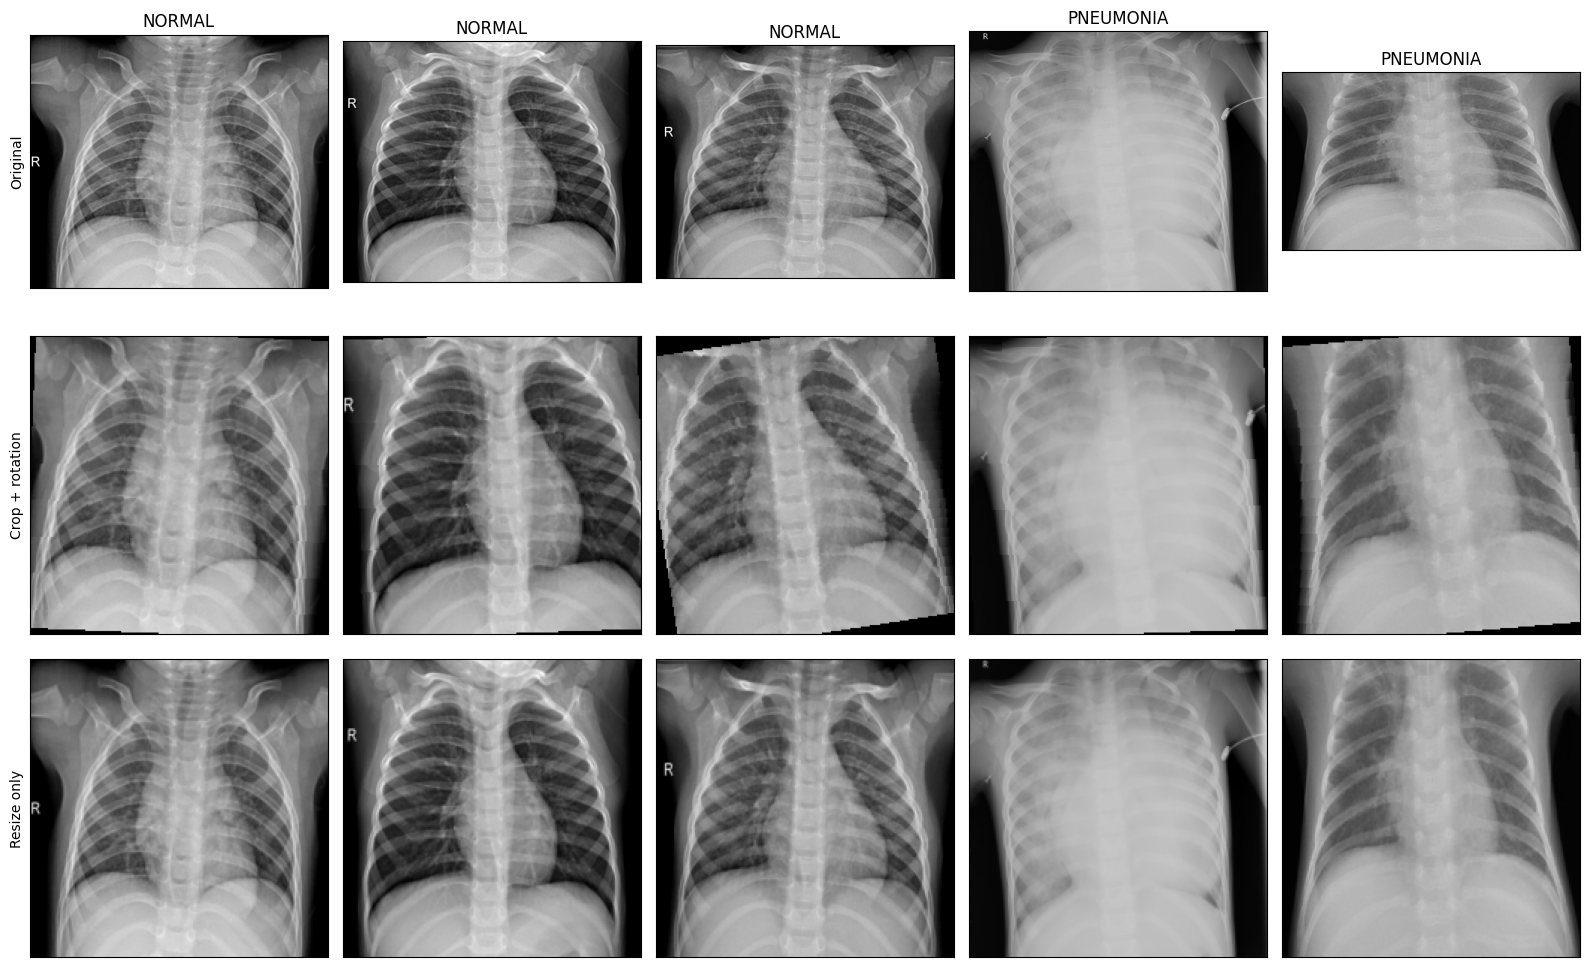

In [27]:
preview_source = files.loc[files["split"] == "train"]
preview = pd.concat([
    preview_source.loc[preview_source["class"] == "NORMAL"].sample(3, random_state=SEED),
    preview_source.loc[preview_source["class"] == "PNEUMONIA"].sample(2, random_state=SEED),
]).reset_index(drop=True)

def display_tensor(tensor):
    # 정규화: (값 - 평균) / 표준편차 → 화면 표시: 값 * 표준편차 + 평균
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# 미리보기 때문에 실제 학습의 난수 상태가 바뀌지 않게 한다.
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(SEED)
    fig, axes = plt.subplots(3, 5, figsize=(16, 10))
    for col, row in preview.iterrows():
        with Image.open(row["file"]) as image:
            rgb = image.convert("RGB")
            axes[0, col].imshow(rgb)
            axes[1, col].imshow(display_tensor(candidate_transform(rgb)))
            axes[2, col].imshow(display_tensor(eval_transform(rgb)))
        axes[0, col].set_title(row["class"])
        for r in range(3):
            axes[r, col].set_xticks([])
            axes[r, col].set_yticks([])
    for r, label in enumerate(["Original", "Crop + rotation", "Resize only"]):
        axes[r, 0].set_ylabel(label)
    plt.tight_layout()
    plt.show()


### 4. 확인 후 증강 적용 여부 결정
그림을 보고 아래 값을 정한다. 우선 `False`로 두어 증강 없는 상태를 기본으로 한다. 후보가 적절하면 `True`로 바꾸고 이 셀부터 다시 실행한다. 회전 강도를 바꾸려면 2번의 각도를 수정하고 후보·미리보기 셀부터 다시 실행한다.

- 내 관찰: (폐 잘림, 회전, 형태 변화를 기록)
- 내 결정과 이유: (증강 사용 여부와 각도를 기록)


In [28]:
USE_AUGMENTATION = False  # 그림 확인 후 사용하려면 True

data_transforms = {
    "train": candidate_transform if USE_AUGMENTATION else eval_transform,
    "val": eval_transform,
    "test": eval_transform,
}
print("학습 증강 사용:", USE_AUGMENTATION)
print("최종 이미지: 3채널, 200 × 200")


학습 증강 사용: False
최종 이미지: 3채널, 200 × 200


### 5. 기존 train에서 새 검증 데이터 약 20% 나누기
**의사코드:** 같은 사진 또는 같은 환자로 추정되는 파일을 묶는다 → 묶음 단위로 train/val을 나눈다 → 클래스별 개수와 중복을 확인한다.

동일 사진을 양쪽에 나누면 검증 점수가 부풀려질 수 있어 함께 묶는다. EDA에서 계산한 픽셀 해시가 있으면 재사용하고, 없으면 기존 train만 계산한다(500장마다 진행 표시). 원본 파일은 이동하거나 삭제하지 않는다.

**20%는 묶음 수 기준**이므로 이미지 수는 정확히 20%가 아닐 수 있다. 클래스 비율을 자동으로 맞추는 분할도 아니므로 출력 표를 확인한다. 파일명은 환자 ID의 추정치이므로 완전한 환자 분리를 보장하지 않는다.
기존 val 16장은 별도로 보관하고, test는 최종 평가용으로 유지한다.


In [29]:
split_table = files.loc[files["split"] == "train"].copy().reset_index(drop=True)

# 이전 EDA 결과가 있으면 파일 경로를 기준으로 재사용한다.
hash_cache = {}
if "meta" in globals() and {"file", "pixel_hash"}.issubset(meta.columns):
    valid_hashes = meta.dropna(subset=["pixel_hash"])
    hash_cache = dict(zip(valid_hashes["file"].map(str), valid_hashes["pixel_hash"]))

hashes = []
for i, file in enumerate(split_table["file"], start=1):
    digest = hash_cache.get(str(file))
    if digest is None:
        with Image.open(file) as image:
            rgb = image.convert("RGB")
            digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
    hashes.append(digest)
    if i % 500 == 0 or i == len(split_table):
        print(f"중복 확인 준비: {i} / {len(split_table)}장")
split_table["pixel_hash"] = hashes

# 같은 환자의 사진으로 추정되는 파일명 앞부분을 추출한다.
def patient_hint(file):
    name = Path(file).name
    for pattern in [r"^(person\d+)_", r"^(NORMAL2-IM-\d+)-", r"^(IM-\d+)-"]:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    return Path(file).stem

split_table["patient_hint"] = split_table["file"].map(patient_hint)

# 같은 환자 추정값 또는 같은 픽셀이면 하나의 묶음으로 연결한다.
parents = list(range(len(split_table)))
def group_root(i):
    while parents[i] != i:
        parents[i] = parents[parents[i]]
        i = parents[i]
    return i

for key in ["patient_hint", "pixel_hash"]:
    first_seen = {}
    for i, value in enumerate(split_table[key]):
        if value in first_seen:
            parents[group_root(i)] = group_root(first_seen[value])
        else:
            first_seen[value] = i
split_table["group"] = [group_root(i) for i in range(len(split_table))]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(split_table, groups=split_table["group"]))
train_table = split_table.iloc[train_idx].copy().reset_index(drop=True)
val_table = split_table.iloc[val_idx].copy().reset_index(drop=True)
test_table = files.loc[files["split"] == "test"].copy().reset_index(drop=True)
original_val_table = files.loc[files["split"] == "val"].copy()

# 같은 사진·환자 추정값이 새 train과 val 양쪽에 있는지 검사한다.
for key in ["pixel_hash", "patient_hint", "group"]:
    overlap = set(train_table[key]) & set(val_table[key])
    print(f"새 train-val 사이 {key} 중복: {len(overlap)}개")
    assert not overlap, f"분할 사이 {key} 중복을 확인해 주세요."
assert len(train_table) + len(val_table) == len(split_table)

summary = pd.DataFrame({
    "train": train_table["class"].value_counts(),
    "val": val_table["class"].value_counts(),
    "test": test_table["class"].value_counts(),
}).T.fillna(0).astype(int)
summary["TOTAL"] = summary.sum(axis=1)
summary["PNEUMONIA_pct"] = summary["PNEUMONIA"] / summary["TOTAL"] * 100
display(summary.round(2))
print(f"새 검증 이미지 비율: {len(val_table) / len(split_table):.1%}")
print("기존 검증 데이터 별도 보관:", len(original_val_table), "장")
print("분할 사이 동일 픽셀 중복은 없음. 분할 내부의 중복 사본은 그대로 유지합니다.")


중복 확인 준비: 500 / 5216장
중복 확인 준비: 1000 / 5216장
중복 확인 준비: 1500 / 5216장
중복 확인 준비: 2000 / 5216장
중복 확인 준비: 2500 / 5216장
중복 확인 준비: 3000 / 5216장
중복 확인 준비: 3500 / 5216장
중복 확인 준비: 4000 / 5216장
중복 확인 준비: 4500 / 5216장
중복 확인 준비: 5000 / 5216장
중복 확인 준비: 5216 / 5216장
새 train-val 사이 pixel_hash 중복: 0개
새 train-val 사이 patient_hint 중복: 0개
새 train-val 사이 group 중복: 0개


class,PNEUMONIA,NORMAL,TOTAL,PNEUMONIA_pct
train,3075,1062,4137,74.33
val,800,279,1079,74.14
test,390,234,624,62.50


새 검증 이미지 비율: 20.7%
기존 검증 데이터 별도 보관: 16 장
분할 사이 동일 픽셀 중복은 없음. 분할 내부의 중복 사본은 그대로 유지합니다.


### 6. 새 분할에 전처리를 연결하고 DataLoader 만들기
**의사코드:** 표의 파일 경로로 이미지를 연다 → RGB로 바꾼다 → 각 용도에 맞는 전처리를 적용한다 → 배치로 묶는다.

원래 폴더 그대로 `ImageFolder`를 다시 만들면 새 분할이 반영되지 않는다. 따라서 위에서 만든 경로 표를 읽는 작은 데이터셋을 사용한다. `__getitem__`은 이미지 한 장을 요청할 때 실행된다. 학습만 순서를 섞고, 검증·테스트는 고정한다.
아래 실행 이후 `train_loader`, `val_loader`는 **새 분할**을 사용한다. 이후 예전 로더 생성 셀을 실행하면 다시 덮어써지므로 주의한다.


In [30]:
class_names = ["NORMAL", "PNEUMONIA"]
class_to_idx = {name: i for i, name in enumerate(class_names)}

class XRayDataset(Dataset):
    def __init__(self, table, transform):
        self.table = table.reset_index(drop=True)
        self.transform = transform
        self.classes = class_names
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        with Image.open(row["file"]) as image:
            image = image.convert("RGB")  # 원본 L/RGB 모두 3채널로 통일
            tensor = self.transform(image)
        label = self.class_to_idx[row["class"]]
        return tensor, label

train_dataset = XRayDataset(train_table, data_transforms["train"])
val_dataset = XRayDataset(val_table, data_transforms["val"])
test_dataset = XRayDataset(test_table, data_transforms["test"])

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 검증 배치 하나로 모양·자료형을 확인한다. 테스트 이미지는 여기서 열지 않는다.
images, labels = next(iter(val_loader))
print("검증 배치 모양:", tuple(images.shape))  # (배치 수, 채널, 높이, 너비)
print("자료형:", images.dtype)
print("정답 번호:", class_to_idx)
assert images.shape[1:] == (3, INPUT_SIZE, INPUT_SIZE)
assert images.dtype == torch.float32
assert torch.isfinite(images).all()
print("전처리와 새 데이터 로더 준비 완료. 아직 모델 학습은 시작하지 않았습니다.")


검증 배치 모양: (32, 3, 200, 200)
자료형: torch.float32
정답 번호: {'NORMAL': 0, 'PNEUMONIA': 1}
전처리와 새 데이터 로더 준비 완료. 아직 모델 학습은 시작하지 않았습니다.


### 전처리 관찰과 결정 기록
- 증강 샘플에서 확인한 점:
- 증강 적용 여부와 회전 각도:
- 새 train/val의 장수와 클래스 비율:
- 새 train-val 사이 동일 이미지 중복 여부:
- 남은 한계: 파일명으로 환자를 추정했으며, 크롭·압축된 유사 사진까지 검출한 것은 아니다.

이후 모델 비교에서는 여기서 확정한 동일 분할을 사용한다. 테스트 성능으로 증강이나 모델 설정을 선택하지 않는다.


## 모델학습

① 사전 학습 모델 불러오기

In [31]:
import torch
from torch import nn
from torchvision import models

# GPU가 연결되어 있으면 GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("학습 장치:", device)

# ImageNet으로 미리 학습된 ResNet18 불러오기
pretrained_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# 기존 가중치는 학습 중 바뀌지 않도록 고정
for parameter in pretrained_model.parameters():
    parameter.requires_grad = False

# 마지막 분류층을 정상·폐렴 2개를 구분하도록 교체
# 새로 만든 층은 기본적으로 학습 가능한 상태
num_classes = 2
in_features = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(in_features, num_classes)

# 모델을 GPU 또는 CPU로 이동
pretrained_model = pretrained_model.to(device)

학습 장치: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 


② 손실함수와 옵티마이저 설정

In [32]:
# 예측과 정답의 차이를 계산
loss_fn = nn.CrossEntropyLoss()

# 새로 만든 마지막 분류층만 Adam으로 학습
optimizer = torch.optim.Adam(
    pretrained_model.fc.parameters(),
    lr=0.001
)

③-1. 한 에폭 학습하는 함수

In [34]:
from tqdm import tqdm

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    # Frozen 모델의 본체는 고정하고 마지막 분류층만 학습
    model.eval()
    model.fc.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="학습", unit="batch"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          # 이전 기울기 초기화
        outputs = model(images)        # 예측
        loss = loss_fn(outputs, labels)

        loss.backward()                # 기울기 계산
        optimizer.step()               # 가중치 업데이트

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size

    return loss_sum / total, correct / total

③-2. 검증하는 함수

In [35]:
def evaluate(model, loader, loss_fn, device):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="평가", unit="batch"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            batch_size = labels.size(0)
            loss_sum += loss.item() * batch_size
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += batch_size

    return loss_sum / total, correct / total, correct, total

④. 학습과 검증 실행하기

In [ ]:
# 먼저 1에폭으로 학습과 검증이 잘 진행되는지 확인
num_epochs = 1

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    # 1. 학습: 마지막 분류층의 가중치를 업데이트
    train_loss, train_acc = train_one_epoch(
        pretrained_model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    # 2. 검증: 가중치를 바꾸지 않고 성능 확인
    val_loss, val_acc, val_correct, val_total = evaluate(
        pretrained_model,
        val_loader,   # 테스트가 아닌 검증 데이터!
        loss_fn,
        device
    )

    print(f"학습 손실: {train_loss:.4f}")
    print(f"학습 정확도: {train_acc:.1%}")

    print(f"검증 손실: {val_loss:.4f}")
    print(f"검증 정확도: {val_acc:.1%}")
    print(f"검증에서 맞힌 이미지: {val_correct}/{val_total}장")


Epoch 1/1


평가: 100%|██████████| 34/34 [00:18<00:00,  1.88batch/s]

학습 손실: 0.1242
학습 정확도: 95.6%
검증 손실: 0.1257
검증 정확도: 95.4%
검증에서 맞힌 이미지: 1029/1079장


In [36]:
torch.save(
    pretrained_model.state_dict(),
    "resnet18_frozen_interrupted.pth"
)
print("중단 시점의 가중치 저장 완료")

중단 시점의 가중치 저장 완료


In [37]:
import requests
from getpass import getpass

# 실행 후 나타나는 입력창에 웹훅 주소 붙여넣기
webhook_url = getpass("디스코드 웹훅 주소: ").strip()

def notify(message):
    try:
        response = requests.post(
            webhook_url,
            params={"wait": "true"},
            json={
                "content": str(message)[:2000],
                "allowed_mentions": {"parse": []}
            },
            timeout=10
        )

        if response.ok:
            print("디스코드 알림 전송 완료!")
        else:
            print(f"알림 전송 실패: HTTP {response.status_code}")

    except requests.RequestException:
        # 알림이 실패해도 학습 코드는 계속 진행
        print("알림 전송 실패: 연결을 확인해 주세요.")

In [38]:
notify("🔔 학습알리미 연결 성공! 유즈랑 설정 완료 ㅎㅎ")

디스코드 알림 전송 완료!


In [ ]:
from pathlib import Path
import pandas as pd

num_epochs = 10  # 이번에 추가로 학습할 횟수
save_dir = Path("checkpoints")
save_dir.mkdir(exist_ok=True)

model_path = save_dir / "resnet18_frozen_best.pth"
history_path = save_dir / "resnet18_frozen_history.csv"

# 같은 연결에서 이 셀을 다시 실행하면 이전 기록을 이어서 사용
if "frozen_history" not in globals():
    frozen_history = []
    frozen_best_val_loss = float("inf")

start_epoch = len(frozen_history)

for epoch in range(num_epochs):
    current_epoch = start_epoch + epoch + 1
    print(f"\nEpoch {current_epoch}")

    # 1. 학습
    train_loss, train_acc = train_one_epoch(
        pretrained_model, train_loader, loss_fn, optimizer, device
    )

    # 2. 검증
    val_loss, val_acc, val_correct, val_total = evaluate(
        pretrained_model, val_loader, loss_fn, device
    )

    print(f"학습 손실: {train_loss:.4f} | 정확도: {train_acc:.1%}")
    print(
        f"검증 손실: {val_loss:.4f} | 정확도: {val_acc:.1%} "
        f"({val_correct}/{val_total}장 정답)"
    )

    # 3. 에폭별 성능 기록 저장
    frozen_history.append({
        "epoch": current_epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    pd.DataFrame(frozen_history).to_csv(history_path, index=False)

    # 4. 이전보다 검증 손실이 낮으면 모델 저장
    if val_loss < frozen_best_val_loss:
        frozen_best_val_loss = val_loss
        torch.save(pretrained_model.state_dict(), model_path)
        print("→ 가장 좋은 모델 저장!")

print("\n모델:", model_path.resolve())
print("학습 기록:", history_path.resolve())


Epoch 1


평가: 100%|██████████| 34/34 [00:17<00:00,  1.91batch/s]


학습 손실: 0.1019 | 정확도: 96.4%
검증 손실: 0.1166 | 정확도: 94.7% (1022/1079장 정답)
→ 가장 좋은 모델 저장!

Epoch 2


평가: 100%|██████████| 34/34 [00:17<00:00,  1.95batch/s]


학습 손실: 0.0910 | 정확도: 96.9%
검증 손실: 0.1194 | 정확도: 95.7% (1033/1079장 정답)

Epoch 3


...

학습 손실: 0.0662 | 정확도: 97.7%
검증 손실: 0.0767 | 정확도: 97.1% (1048/1079장 정답)
→ 가장 좋은 모델 저장!

Epoch 9


평가: 100%|██████████| 34/34 [00:17<00:00,  1.94batch/s]


학습 손실: 0.0643 | 정확도: 98.0%
검증 손실: 0.0756 | 정확도: 97.1% (1048/1079장 정답)
→ 가장 좋은 모델 저장!

Epoch 10


평가: 100%|██████████| 34/34 [00:17<00:00,  1.97batch/s]

학습 손실: 0.0630 | 정확도: 97.9%
검증 손실: 0.0728 | 정확도: 97.2% (1049/1079장 정답)
→ 가장 좋은 모델 저장!

모델: /kaggle/working/checkpoints/resnet18_frozen_best.pth
학습 기록: /kaggle/working/checkpoints/resnet18_frozen_history.csv


## 증강 없는 모델 4종 비교
① 모델 만드는 셀

In [39]:
import time
from pathlib import Path

import pandas as pd
import torch
from torch import nn
from torchvision import models
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("학습 장치:", device)


# 비교용으로 처음부터 학습할 간단한 CNN
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_model(experiment):
    # 실험마다 같은 시드에서 새 모델 생성
    torch.manual_seed(42)

    if experiment == "custom":
        return CustomCNN().to(device)

    # 매번 원래 사전 학습 가중치에서 시작
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )
    model.fc = nn.Linear(model.fc.in_features, 2)

    # 우선 전체 고정
    for parameter in model.parameters():
        parameter.requires_grad = False

    if experiment == "frozen":
        # 마지막 분류층만 학습
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif experiment == "partial":
        # 마지막 특징 추출 블록 + 분류층 학습
        for layer in [model.layer4, model.fc]:
            for parameter in layer.parameters():
                parameter.requires_grad = True

    elif experiment == "full":
        # 전체 학습
        for parameter in model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError("custom, frozen, partial, full 중 선택하세요.")

    return model.to(device)

학습 장치: cuda


② 학습 함수와 검증 함수

In [40]:
def train_comparison_epoch(model, experiment, loader, loss_fn, optimizer):
    # 고정한 부분의 BatchNorm 통계도 유지
    if experiment == "frozen":
        model.eval()
        model.fc.train()

    elif experiment == "partial":
        model.eval()
        model.layer4.train()
        model.fc.train()

    else:
        model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="학습", unit="batch"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (outputs.argmax(1) == labels).sum().item()
        total += batch_size

    return loss_sum / total, correct / total


def validate_comparison(model, loader, loss_fn):
    model.eval()

    loss_sum = 0.0
    answers = []
    predictions = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="검증", unit="batch"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            loss_sum += loss.item() * labels.size(0)
            answers.extend(labels.cpu().tolist())
            predictions.extend(outputs.argmax(1).cpu().tolist())

    return {
        "val_loss": loss_sum / len(answers),
        "accuracy": accuracy_score(answers, predictions),
        "precision": precision_score(
            answers, predictions, pos_label=1, zero_division=0
        ),
        "recall": recall_score(
            answers, predictions, pos_label=1, zero_division=0
        ),
        "f1": f1_score(
            answers, predictions, pos_label=1, zero_division=0
        ),
    }

③ 실험 실행·저장 함수

In [41]:
from datetime import datetime
from uuid import uuid4

# 처음 시도할 학습률: 미세조정 범위가 넓을수록 작게 설정
learning_rates = {
    "custom": 0.001,
    "frozen": 0.001,
    "partial": 0.0001,
    "full": 0.00001,
}


def run_experiment(experiment, epochs=10):
    if USE_AUGMENTATION:
        raise ValueError("증강을 끄고 데이터 로더를 다시 만들어 주세요.")

    # 현재 로더에도 증강 없는 변환이 연결되어 있는지 확인
    if train_dataset.transform is not data_transforms["val"]:
        raise ValueError("전처리 선택 셀과 로더 생성 셀을 다시 실행하세요.")

    # 학습 데이터의 섞이는 순서를 실험마다 초기화
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(42)

    model = build_model(experiment)
    loss_fn = nn.CrossEntropyLoss()
    lr = learning_rates[experiment]

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = (
        Path("experiments")
        / f"{experiment}_{run_id}_{uuid4().hex[:6]}"
    )
    save_dir.mkdir(parents=True)

    history = []
    best_loss = float("inf")
    best_result = None
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        print(f"\n[{experiment}] Epoch {epoch}/{epochs}")

        train_loss, train_acc = train_comparison_epoch(
            model, experiment, train_loader, loss_fn, optimizer
        )
        metrics = validate_comparison(model, val_loader, loss_fn)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            **metrics,
        }
        history.append(row)

        # 매 에폭 기록 저장
        pd.DataFrame(history).to_csv(
            save_dir / "history.csv", index=False
        )

        print(
            f"학습 정확도: {train_acc:.1%} | "
            f"검증 손실: {metrics['val_loss']:.4f} | "
            f"검증 정확도: {metrics['accuracy']:.1%}\n"
            f"Precision: {metrics['precision']:.3f} | "
            f"Recall: {metrics['recall']:.3f} | "
            f"F1: {metrics['f1']:.3f}"
        )

        # 모든 모델에 동일한 선택 기준 적용
        if metrics["val_loss"] < best_loss:
            best_loss = metrics["val_loss"]
            best_result = {
                "experiment": experiment,
                "best_epoch": epoch,
                "learning_rate": lr,
                **metrics,
            }

            # 가중치와 해당 시점의 학습 설정을 함께 저장
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "experiment": experiment,
                "epoch": epoch,
                "learning_rate": lr,
                "class_names": class_names,
                "input_size": INPUT_SIZE,
                "mean": MEAN,
                "std": STD,
                "augmentation": False,
                "seed": 42,
            }, save_dir / "best.pth")

            # 중간에 중단돼도 완료된 최선의 결과는 남김
            pd.DataFrame([best_result]).to_csv(
                save_dir / "best_result.csv", index=False
            )
            print("→ 가장 좋은 모델 저장!")

    best_result["total_minutes"] = (
        time.perf_counter() - start_time
    ) / 60
    best_result["save_dir"] = str(save_dir)

    pd.DataFrame([best_result]).to_csv(
        save_dir / "best_result.csv", index=False
    )

    print("\n완료! 저장 위치:", save_dir.resolve())

    # 앞에서 연결한 디스코드 알림 사용
    if callable(globals().get("notify")):
        notify(
            f"✅ {experiment} 실험 완료!\n"
            f"최선의 에폭: {best_result['best_epoch']}\n"
            f"검증 정확도: {best_result['accuracy']:.1%}\n"
            f"검증 F1: {best_result['f1']:.3f}"
        )

    # 다음 실험을 위해 GPU 메모리 정리
    del optimizer, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_result

④ 모델 하나 선택해서 실행

In [20]:
# 선택: "custom", "frozen", "partial", "full"
EXPERIMENT = "custom"

result = run_experiment(
    experiment=EXPERIMENT,
    epochs=10
)

display(pd.DataFrame([result]))

NameError: name 'run_experiment' is not defined

In [42]:
# CustomCNN을 처음부터 20에폭 학습하는 추가 실험
custom_20_result = run_experiment("custom", epochs=20)

display(pd.DataFrame([custom_20_result]))


[custom] Epoch 1/20


검증: 100%|██████████| 34/34 [00:18<00:00,  1.82batch/s]


학습 정확도: 74.3% | 검증 손실: 0.5329 | 검증 정확도: 74.1%
Precision: 0.741 | Recall: 1.000 | F1: 0.852
→ 가장 좋은 모델 저장!

[custom] Epoch 2/20


검증: 100%|██████████| 34/34 [00:17<00:00,  1.98batch/s]


학습 정확도: 79.3% | 검증 손실: 0.3667 | 검증 정확도: 86.1%
Precision: 0.937 | Recall: 0.871 | F1: 0.903
→ 가장 좋은 모델 저장!

[custom] Epoch 3/20


...

검증: 100%|██████████| 34/34 [00:17<00:00,  1.93batch/s]


학습 정확도: 94.1% | 검증 손실: 0.1688 | 검증 정확도: 93.9%
Precision: 0.982 | Recall: 0.935 | F1: 0.958

[custom] Epoch 20/20


검증: 100%|██████████| 34/34 [00:17<00:00,  1.90batch/s]


학습 정확도: 93.9% | 검증 손실: 0.1484 | 검증 정확도: 94.4%
Precision: 0.951 | Recall: 0.975 | F1: 0.963
→ 가장 좋은 모델 저장!

완료! 저장 위치: /kaggle/working/experiments/custom_20261001_151022_365ace
디스코드 알림 전송 완료!


,experiment,best_epoch,learning_rate,val_loss,accuracy,precision,recall,f1,total_minutes,save_dir
0,custom,20,0.001,0.148379,0.944393,0.95122,0.975,0.962963,29.683399,experiments/custom_20261001_151022_365ace


⑤ 완료된 실험 결과 모아보기

In [ ]:
result_files = sorted(
    Path("experiments").glob("*/best_result.csv")
)

if result_files:
    comparison = pd.concat(
        [pd.read_csv(file) for file in result_files],
        ignore_index=True
    )
    display(comparison.round(4))
else:
    print("아직 저장된 실험 결과가 없습니다.")

In [ ]:
# for 반복문 밖에, 들여쓰기 없이 작성
notify(
    f"✅ Frozen 학습 완료!\n"
    f"마지막 검증 손실: {val_loss:.4f}\n"
    f"마지막 검증 정확도: {val_acc:.1%}"
)

디스코드 알림 전송 완료!


## 개인 참고용 — EDA~전처리 변수 사전

> 발표용 내용이 아니라, 혼자 코드를 읽을 때 찾아보는 참고표입니다.
> 아래 값과 장수는 현재 설정·실행 결과 기준이며 설정을 바꾸면 달라질 수 있습니다.


### 정답 클래스와 파이썬 클래스 구분

| 구분 | 이름 | 의미 |
|---|---|---|
| 정답 클래스 | `NORMAL` | 정상, 정답 번호 **0** |
| 정답 클래스 | `PNEUMONIA` | 폐렴, 정답 번호 **1** |
| 파이썬 클래스 | `XRayDataset` | 사진을 열고 전처리한 뒤 정답과 함께 반환하도록 만든 코드 |


### ① 공통 설정

| 이름 | 현재 값 | 역할 |
|---|---|---|
| `SEED` | `42` | 랜덤 선택·분할을 다시 재현하기 위한 기준 |
| `CLASSES` | `["NORMAL", "PNEUMONIA"]` | EDA에서 사용하는 클래스 이름 목록 |
| `class_names` | `["NORMAL", "PNEUMONIA"]` | 전처리 이후 사용하는 클래스 이름 목록 |
| `class_to_idx` | `{"NORMAL": 0, "PNEUMONIA": 1}` | 클래스 이름을 정답 번호로 바꾸는 사전 |
| `DATA_ROOT` | 데이터 폴더 경로 | 원본 train·val·test가 있는 위치 |

`CLASSES`와 `class_names`는 이름만 다르고 같은 클래스 목록이다.


### ② EDA에서 데이터를 확인하는 변수

여기서 ‘표’는 pandas의 `DataFrame`을 뜻한다.

| 이름 | 담긴 내용 | 사용하는 이유 |
|---|---|---|
| `records` | 이미지 경로와 클래스 정보를 모은 목록 | `files` 표를 만들기 위한 준비 |
| **`files`** | 전체 이미지의 소속·클래스·경로·파일명 표 | EDA와 전처리의 기본 이미지 목록 |
| `counts` | 원본 train·val·test의 클래스별 장수 | 클래스 불균형 확인 |
| `majority_class` | 학습 데이터에서 가장 많은 클래스 | 항상 같은 답을 할 때의 기준선 계산 |
| `info` | 학습 이미지의 너비·높이·모드·비율·픽셀 수 | 원본 규격 확인 |
| `wide` | 가로세로 비율이 큰 이미지 5장 | 가로로 긴 사진 확인 |
| `small` | 픽셀 수가 적은 이미지 5장 | 작은 사진 확인 |
| `rng` | 랜덤으로 뽑는 도구 | 같은 시드로 샘플 선택 |
| `selected` | 클래스별로 고른 샘플 이미지 경로 | 정상·폐렴 각 15장 시각화 |
| `meta` | 전체 이미지 정보와 중복 검사값을 담는 표 | 기존 EDA의 크기 분석·중복 검사 |
| `train_meta` | `meta`에서 학습 데이터만 고른 표 | 학습 이미지의 크기 분포 분석 |
| `n_val` | 원래 검증 이미지 수, `16` | 작은 검증셋의 한계 확인 |
| `proposal` | EDA에서 시험 삼아 만든 분할 후보 표 | 새 train·val 분할을 미리 검토 |

**현재 파일의 실행 메모:** `meta`를 만드는 셀은 주석 처리되어 있다. 커널을 새로 시작하면 `meta`를 사용하는 기존 EDA 셀은 그대로 실행되지 않는다. 새 전처리는 `files`만 있어도 진행하도록 구성되어 있다.


### ③ 전처리 설정과 변환

| 이름 | 현재 값·내용 | 쉬운 설명 |
|---|---|---|
| `RESIZE_SIZE` | `224` | 증강 후보에서 크롭하기 전 크기 |
| **`INPUT_SIZE`** | **`200`** | 모델에 들어가는 최종 이미지 크기 |
| `BATCH_SIZE` | `32` | 한 번에 묶어서 가져오는 이미지 수 |
| `ROTATION_DEGREES` | `10` | 랜덤 회전 범위: −10도~+10도 |
| `MEAN` | `(0.485, 0.456, 0.406)` | RGB 각 채널의 정규화에 사용하는 평균 |
| `STD` | `(0.229, 0.224, 0.225)` | RGB 각 채널의 정규화에 사용하는 표준편차 |
| `candidate_transform` | 크기 변경 → 랜덤 크롭·회전 → 텐서·정규화 | 그림으로 확인할 증강 후보 |
| `eval_transform` | 200×200 변경 → 텐서·정규화 | 랜덤 증강 없는 변환 |
| **`USE_AUGMENTATION`** | **`False`** | 학습에 증강을 사용할지 정하는 스위치 |
| **`data_transforms`** | train·val·test별 변환 사전 | 각 데이터에 어떤 전처리를 적용할지 지정 |
| `preview_source` | 기존 train 이미지 목록 | 미리보기 샘플을 고르는 대상 |
| `preview` | 정상 3장·폐렴 2장 | 전처리 전후를 비교할 5장 |
| `display_tensor()` | 화면 표시용 함수 | 정규화를 되돌려 그림으로 보여줌 |

`MEAN`, `STD`는 우리 사진에서 계산한 값이 아니라 사전 학습 모델에 맞춘 ImageNet 기준값이다.

현재는 증강이 꺼져 있어서 train도 `eval_transform`을 사용한다. 켜면 **224 → 200 크롭 → 회전**을 적용하고, 다시 224로 키우지 않는다.


### ④ 새 train·val 분할과 중복 확인

| 이름 | 담긴 내용·역할 |
|---|---|
| `split_table` | 기존 train 전체를 가져와 새로 나눌 준비를 한 표 |
| `hash_cache` | EDA에서 이미 계산한 픽셀 해시를 재사용하기 위한 사전 |
| `hashes` | 이미지별 픽셀 해시를 모은 목록 |
| `patient_hint()` | 파일명에서 환자 구분에 쓸 추정값을 뽑는 함수 |
| `parents`, `group_root()` | 같은 사진·같은 환자로 추정되는 파일을 한 묶음으로 연결하는 코드 |
| `splitter` | 묶음을 유지하며 약 80:20으로 나누는 도구 |
| `train_idx`, `val_idx` | 각 분할에 들어갈 행 번호 |
| **`train_table`** | 새 학습 이미지 목록: **4,137장** |
| **`val_table`** | 새 검증 이미지 목록: **1,079장** |
| `test_table` | 원래 테스트 이미지 목록: **624장** |
| `original_val_table` | 따로 보관한 기존 검증 이미지 목록: **16장** |
| `overlap` | 새 train과 val 양쪽에 겹치는 값 |
| `summary` | 분할별 장수·클래스 비율을 정리한 결과 표 |

20%는 묶음 수 기준이므로 이미지 수의 정확한 20%는 아니다. 환자 구분은 파일명에서 추정한 것으로, 완전한 환자 분리를 보장하지는 않는다.


### ⑤ 실제 학습으로 연결되는 이름 — 가장 중요!

| 이름 | 역할 |
|---|---|
| `XRayDataset` | 표에서 사진 경로를 읽고, RGB 변환·전처리를 적용하는 데이터셋 클래스 |
| `train_dataset` | 새 학습 이미지와 학습용 전처리를 연결한 데이터셋 |
| `val_dataset` | 새 검증 이미지와 검증용 전처리를 연결한 데이터셋 |
| `test_dataset` | 테스트 이미지와 테스트용 전처리를 연결한 데이터셋 |
| **`train_loader`** | 학습 데이터를 최대 32장씩 묶어서 제공. 순서를 섞음 |
| **`val_loader`** | 검증 데이터를 최대 32장씩 묶어서 제공. 순서를 유지 |
| **`test_loader`** | 최종 평가 데이터를 최대 32장씩 묶어서 제공 |
| `generator` | 학습 데이터를 섞는 순서에 사용할 난수 도구 |
| `images` | 로더에서 가져온 이미지 한 배치 |
| `labels` | 그 이미지들의 정답 번호 한 배치 |

**변수의 연결 흐름**

| 순서 | 이름 | 하는 일 |
|---|---|---|
| 1 | `files` | 전체 이미지 목록 준비 |
| 2 | `train_table` / `val_table` | 새 학습·검증 목록으로 나누기 |
| 3 | `train_dataset` / `val_dataset` | 사진 읽기 + 전처리 + 정답 연결 |
| 4 | `train_loader` / `val_loader` | 여러 장씩 배치로 묶기 |
| 5 | `images`, `labels` | 모델에 전달할 이미지와 정답 |


### ⑥ 따옴표 안의 이름 — 표의 열 이름

`files["class"]`의 `"class"`처럼 따옴표로 쓰인 이름은 여기서는 표의 열 이름이다.

| 주요 열 이름 | 뜻 |
|---|---|
| `"split"` | 원래 소속: train·val·test |
| `"class"` | 정답 이름: NORMAL·PNEUMONIA |
| `"file"` / `"name"` | 전체 파일 경로 / 파일명 |
| `"width"` / `"height"` | 너비 / 높이 |
| `"mode"` / `"channels"` | 저장 모드 / 채널 수 |
| `"aspect_ratio"` | 너비 ÷ 높이 |
| `"file_hash"` / `"pixel_hash"` | 파일 내용 / 픽셀 내용의 중복 비교값 |
| `"patient_hint"` / `"group"` | 환자 추정값 / 함께 분할할 묶음 번호 |

`info` 표에서는 같은 의미의 정보를 `"너비"`, `"높이"`, `"모드"`, `"가로세로비"`, `"픽셀수"`라는 한글 열 이름으로 저장한다.

`file`, `row`, `i`, `col` 같은 짧은 이름은 반복문에서 잠깐 쓰는 이름이다. **그 이름이 나온 셀 안에서 무엇을 하나씩 가져오는지** 확인하면 된다. 같은 변수 이름은 뒤 셀에서 다시 지정될 수 있으며, 마지막으로 실행한 값이 남는다.
